In [ ]:
# Bootstrap: add mlpython/ to sys.path so `lib` is importable (cwd = this notebook's dir)
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))


In [56]:
import numpy as np
import matplotlib.pyplot as plt

import os
import glob
import re
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR = "../../valid_points_lhe"    # Carpeta con archivos .lha
INPUT_CSV = "valid_points_extended.csv"

# Get from LHE

Reads the LHE files in order to get the known valid points, getting the the list of important parameters

In [57]:
df = pd.read_csv(INPUT_CSV)
df.columns

Index(['file', 'tan_beta', 'lambda1', 'lambda2', 'lambda3', 'lambda4',
       'lambda5', 'lambda6', 'lambda7', 'm12_2', 'sin_ba', 'cos_ba',
       'yukawa_type', 'Mh1', 'Mh2', 'Mh3', 'MHp', 'valid_param',
       'unitarity_ok', 'perturbativity_ok', 'stability_ok', 'total_width_h2',
       'BR_h2_W_W', 'BR_h2_Z_Z', 'BR_h2_Z_ga', 'BR_h2_b_b', 'BR_h2_c_c',
       'BR_h2_e_e', 'BR_h2_g_g', 'BR_h2_ga_ga', 'BR_h2_mu_mu', 'BR_h2_s_s',
       'BR_h2_t_t', 'BR_h2_ta_ta'],
      dtype='object')

In [ ]:
# comprobación
# assert para que todo sea igual a 1
df[['BR_h2_W_W', 'BR_h2_Z_Z',
       'BR_h2_Z_ga', 'BR_h2_b_b', 'BR_h2_c_c', 'BR_h2_e_e', 'BR_h2_g_g',
       'BR_h2_ga_ga', 'BR_h2_mu_mu', 'BR_h2_s_s', 'BR_h2_t_t', 'BR_h2_ta_ta']].sum(axis=1)

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
dtype: float64

In [61]:
df[['Mh1','Mh2','Mh3','MHp','sin_ba','lambda1','lambda6','lambda7']]

,Mh1,Mh2,Mh3,MHp,sin_ba,lambda1,lambda6,lambda7
0,125.0,130.000000,300.0,300.0,1.0,1.020619,0.1,0.0
1,125.0,139.999999,300.0,300.0,1.0,0.976086,0.1,0.0
2,125.0,150.000001,300.0,300.0,1.0,0.928255,0.1,0.0
3,125.0,160.000000,300.0,300.0,1.0,0.877126,0.1,0.0
4,125.0,170.000001,300.0,300.0,1.0,0.822698,0.1,0.0
5,125.0,180.000000,300.0,300.0,1.0,0.764971,0.1,0.0
6,125.0,190.000000,300.0,300.0,1.0,0.703945,0.1,0.0
7,125.0,200.000000,300.0,300.0,1.0,0.639621,0.1,0.0
8,125.0,210.000000,300.0,300.0,1.0,0.571998,0.1,0.0
9,125.0,220.000000,300.0,300.0,1.0,0.501076,0.1,0.0


In [62]:
# ----- -set de values- ---------
cols = ['tan_beta','lambda6', 'lambda7', 'sin_ba',
       'yukawa_type', 'Mh3', 'MHp']
# calcular el set de valores de cada columna
values_set = {col: set(df[col].dropna().unique()) for col in cols}
values_set

# se encuentra que hay un dato sin_ba que es 0, algun typo?

{'tan_beta': {np.float64(10000.0)},
 'lambda6': {np.float64(0.1)},
 'lambda7': {np.float64(0.0)},
 'sin_ba': {np.float64(1.0)},
 'yukawa_type': {np.float64(1.0)},
 'Mh3': {np.float64(300.0)},
 'MHp': {np.float64(300.0)}}

In [65]:
# solo se encuentran en las regiones
# donde m_phi < 125
# por convención es correcto
df[df['sin_ba']==0]

,file,tan_beta,lambda1,lambda2,lambda3,lambda4,lambda5,lambda6,lambda7,m12_2,...,BR_h2_Z_ga,BR_h2_b_b,BR_h2_c_c,BR_h2_e_e,BR_h2_g_g,BR_h2_ga_ga,BR_h2_mu_mu,BR_h2_s_s,BR_h2_t_t,BR_h2_ta_ta


In [35]:
# ---- filtrado ----
df = df[df['sin_ba']!=0]

In [66]:
# get beta
df['beta'] = pd.Series([np.arctan(tb) for tb in df['tan_beta']])
df['sin_beta'] = np.sin(df['beta'])
df['cos_beta'] = np.cos(df['beta'])


In [67]:
print(df.head())

      file  tan_beta   lambda1   lambda2   lambda3   lambda4   lambda5  \
0  130.lha   10000.0  1.020619  0.257734  2.669307 -1.205802 -1.205802   
1  140.lha   10000.0  0.976086  0.257734  2.580235 -1.161265 -1.161265   
2  150.lha   10000.0  0.928255  0.257734  2.484564 -1.113430 -1.113430   
3  160.lha   10000.0  0.877126  0.257734  2.382295 -1.062296 -1.062296   
4  170.lha   10000.0  0.822698  0.257734  2.273428 -1.007862 -1.007862   

   lambda6  lambda7     m12_2  ...     BR_h2_e_e  BR_h2_g_g  BR_h2_ga_ga  \
0      0.1      0.0  1.689909  ...  3.166108e-09   0.050770     0.445387   
1      0.1      0.0  1.959909  ...  2.835660e-09   0.052523     0.466389   
2      0.1      0.0  2.249909  ...  2.530328e-09   0.053702     0.481950   
3      0.1      0.0  2.559909  ...  2.254750e-09   0.054452     0.493267   
4      0.1      0.0  2.889909  ...  2.009622e-09   0.054898     0.501370   

   BR_h2_mu_mu  BR_h2_s_s  BR_h2_t_t  BR_h2_ta_ta      beta  sin_beta  \
0     0.000135   0.000143

Procedemos a calcular $\bar m^2$ la cual es la variable fundamental
$$
\bar m^2 = \frac{m_{12}^2}{\sin \beta \cos \beta}
$$

In [68]:
df['mbar'] = df['m12_2'] / ( df['sin_beta'] * df['cos_beta'] )

(array([6., 5., 3., 4.]),
 array([16899.09016897, 35174.09037671, 53449.09058444, 71724.09079217,
        89999.09099991]),
 <BarContainer object of 4 artists>)

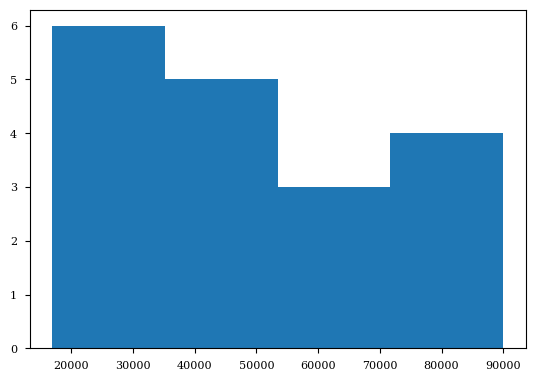

In [69]:
# los valores de m_bar en este casoson bastante aleatorios
plt.hist(df['mbar'], bins=int(np.sqrt(len(df))))

# Como calza con las expresiones analiticas?

In [70]:

from lib.utils import estimate_exploration_time, expand_parameter_space
import numpy as np
import matplotlib.pyplot as plt

from lib.oracle import run_oracle, safe_run_oracle

def physpoint(mphi: float, m12_2: float, mA: float = 300.0, sin_ba=1, tanbeta=1e4, lambda6=0.1, lambda7=0.0):
    # Llama al modelo con valores fijos y retorna el diccionario de resultados
    return safe_run_oracle([mphi, mA, sin_ba, tanbeta, lambda6, lambda7, m12_2])


In [71]:
# diccionario de valores m_phi y m_12_2
points = {
    'mphi': df.Mh2,
    'm12_2': df.m12_2
}

In [72]:
# select point with key 0


In [73]:
physpoint(points['mphi'][5], points['m12_2'][5])

{'positivity_ok': 1,
 'unitarity_ok': 1,
 'perturbativity_ok': 1,
 'w_h2_bb': 3.602235687283826e-11,
 'w_h2_tautau': 3.727577358127279e-12,
 'w_h2_uu': 0.0,
 'w_h2_du': 0.0,
 'w_h2_ln': 0.0,
 'w_h2_vv': [8.722140847542415e-11, 0.0, 0.0],
 'w_h2_gaga': 8.722140847542415e-11,
 'w_h2_Zga': 3.384195106855107e-11,
 'w_h2_gg': 9.272937421049987e-12,
 'w_h2_hh': 0.0,
 'w_total_h2': 1.717225470710792e-10,
 'w_total_top': 1.338069402459526,
 'branching_ratio_h2_gaga': 0.5079205378855788,
 'lambda1': 0.7649707726375254,
 'lambda2': 0.257733792616623,
 'lambda3': 2.157963503891326,
 'lambda4': -0.9501298581735511,
 'lambda5': -0.9501298581735514,
 'lambda6': 0.1,
 'lambda7': 0.0}

In [74]:
np_phihh = []
np_total = []
for i in points['mphi'].index:
    decays = physpoint(points['mphi'][i], points['m12_2'][i])
    phi_hh = decays['w_h2_hh']
    phi_total = decays['w_total_h2']
    np_phihh.append(phi_hh)
    np_total.append(phi_total)

np_phihh = np.array(np_phihh)
np_total = np.array(np_total)

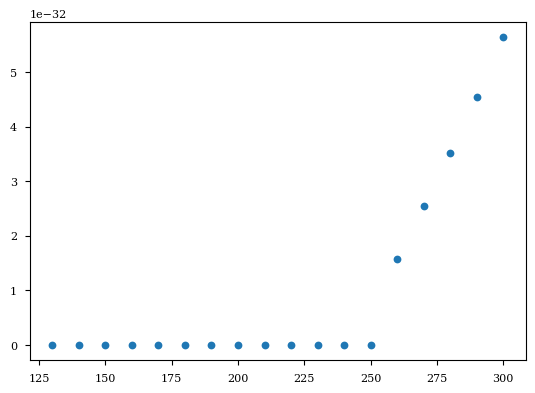

In [75]:
plt.plot(points['mphi'], np_phihh, 'o')

# Visualizar los BR presentes

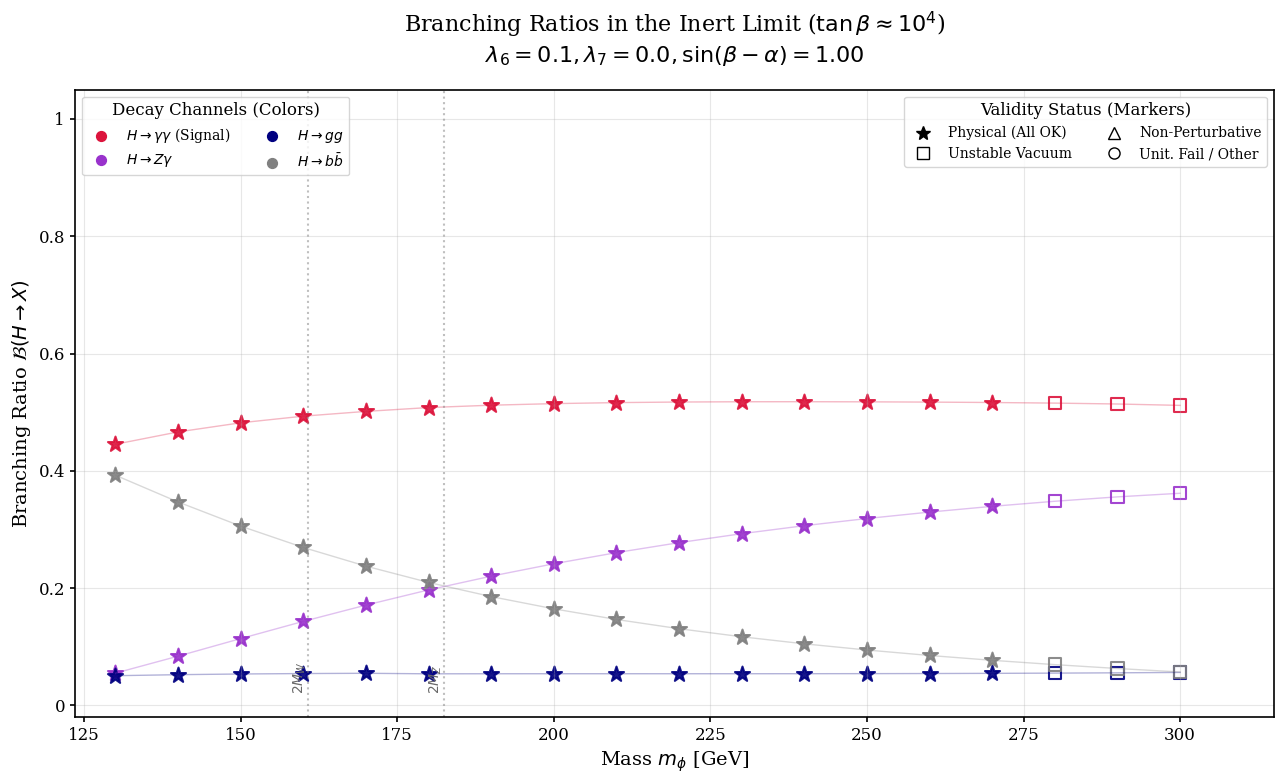

In [78]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
if 'df' not in locals():
    try:
        df = pd.read_csv("valid_points_extended.csv")
    except:
        print("⚠️ Usando datos dummy para visualización.")
        df = pd.DataFrame({
            'm_phi': np.linspace(130, 300, 25),
            'BR_h2_ga_ga': np.abs(np.random.randn(25)*0.1),
            'BR_h2_Z_ga': np.abs(np.random.randn(25)*0.05),
            'unitarity_ok': np.random.randint(0,2,25),
            'perturbativity_ok': np.random.randint(0,2,25),
            'stability_ok': np.random.randint(0,2,25),
            'lambda6': 0.1, 'lambda7': 0.0, 'sin_ba': 1.0
        })

# Extraer parámetros para el título
l6_val = df['lambda6'].mean() if 'lambda6' in df.columns else 0.1
l7_val = df['lambda7'].mean() if 'lambda7' in df.columns else 0.0
sba_val = df['sin_ba'].mean() if 'sin_ba' in df.columns else 1.0

# Ordenar por masa
df_sorted = df.sort_values('m_phi').copy()

# ==========================================
# 2. CONFIGURACIÓN DEL GRÁFICO
# ==========================================
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12, 
    'font.family': 'serif',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

fig, ax = plt.subplots(figsize=(13, 8)) # Un poco más ancho para las leyendas

# --- DICCIONARIO DE CANALES (Significado de los Colores) ---
channels = {
    'BR_h2_ga_ga': (r'$H \to \gamma\gamma$ (Signal)', 'crimson',     2.5),
    'BR_h2_Z_ga':  (r'$H \to Z\gamma$',                'darkorchid',  2.0),
    'BR_h2_g_g':   (r'$H \to gg$',                     'navy',        1.5),
    'BR_h2_b_b':   (r'$H \to b\bar{b}$',               'gray',        1.0),
    'BR_h2_W_W':   (r'$H \to W^+W^-$',                 'orange',      1.5),
    'BR_h2_Z_Z':   (r'$H \to ZZ$',                     'forestgreen', 1.5)
}

# --- LÓGICA DE MARCADORES (Significado de los Símbolos) ---
def get_marker_props(row):
    u = row.get('unitarity_ok', 1)
    p = row.get('perturbativity_ok', 1)
    s = row.get('stability_ok', 1)
    
    if u and p and s:
        return '*', 'full', 130 # Estrella (Físico)
    elif u and p and not s:
        return 's', 'none', 80  # Cuadrado vacío (Inestable)
    elif u and s and not p:
        return '^', 'none', 80  # Triángulo vacío (No perturbativo)
    else:
        return 'o', 'none', 60  # Círculo (Fallo grave)

# --- PLOTTING ---
# 1. Dibujar líneas y puntos
for col, (label, color, base_lw) in channels.items():
    if col not in df_sorted.columns: continue
    
    # Filtro de datos válidos
    data = df_sorted[df_sorted[col] > 1e-9]
    if data.empty: continue

    # Truco: Ploteamos un scatter vacío con etiqueta para que aparezca en la leyenda de colores
    # pero sin ensuciar el gráfico con un punto gigante
    ax.scatter([], [], color=color, label=label, s=50, marker='o')

    # Ploteo real punto a punto para variar marcadores
    for idx, row in data.iterrows():
        marker, fill, size = get_marker_props(row)
        face_color = color if fill == 'full' else 'none'
        
        ax.scatter(
            row['m_phi'], row[col],
            color=color, facecolors=face_color,
            marker=marker, s=size, linewidth=1.5, alpha=0.9
        )
        
    # Opcional: Línea tenue conectando puntos para guiar el ojo
    ax.plot(data['m_phi'], data[col], color=color, alpha=0.3, linewidth=1, linestyle='-')

# --- DECORACIÓN ---
title_str = (r"Branching Ratios in the Inert Limit ($\tan\beta \approx 10^4$)"
             f"\n"
             fr"$\lambda_6={l6_val:.1f}, \lambda_7={l7_val:.1f}, \sin(\beta-\alpha)={sba_val:.2f}$")
ax.set_title(title_str, fontsize=16, pad=20) # pad mayor para separar del contenido

ax.set_xlabel(r'Mass $m_\phi$ [GeV]', fontsize=14)
ax.set_ylabel(r'Branching Ratio $\mathcal{B}(H \to X)$', fontsize=14)

# Límites
ax.set_xlim(df_sorted['m_phi'].min()*0.95, df_sorted['m_phi'].max()*1.05)
ax.set_ylim(-0.02, 1.05) # Un poco de espacio abajo y arriba

# Umbrales verticales
thresholds = {r'$2M_W$': 160.8, r'$2M_Z$': 182.4, r'$t\bar{t}$': 345.0}
for txt, val in thresholds.items():
    if val < ax.get_xlim()[1]:
        ax.axvline(val, color='gray', linestyle=':', alpha=0.5)
        ax.text(val, 0.02, txt, rotation=90, va='bottom', ha='right', fontsize=10, color='dimgray')

ax.grid(True, which="major", linestyle='-', alpha=0.3)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

# ==========================================
# 3. CONFIGURACIÓN DE LEYENDAS (DUAL)
# ==========================================
# Leyenda 1: Canales (Colores) -> Ubicada arriba a la izquierda
# Usamos 'bbox_to_anchor' para ponerla justo encima del eje X o Y si fuera necesario, 
# pero 'upper left' suele estar libre si los BRs no son todos 1.
legend1 = ax.legend(loc='upper left', ncol=2, fontsize=10, 
                    title="Decay Channels (Colors)", frameon=True, fancybox=True)
legend1.get_frame().set_alpha(0.8) # Semi-transparente

# Leyenda 2: Validación (Marcadores) -> Ubicada arriba a la derecha
markers_legend = [
    Line2D([0], [0], color='k', marker='*', linestyle='None', markersize=10, label='Physical (All OK)'),
    Line2D([0], [0], color='k', marker='s', linestyle='None', markersize=8, markerfacecolor='none', label='Unstable Vacuum'),
    Line2D([0], [0], color='k', marker='^', linestyle='None', markersize=8, markerfacecolor='none', label='Non-Perturbative'),
    Line2D([0], [0], color='k', marker='o', linestyle='None', markersize=8, markerfacecolor='none', label='Unit. Fail / Other')
]

# Creamos la segunda leyenda manualmente
legend2 = ax.legend(handles=markers_legend, loc='upper right', ncol=2, fontsize=10, 
                    title="Validity Status (Markers)", frameon=True, fancybox=True)
legend2.get_frame().set_alpha(0.8)

# ¡IMPORTANTE! Matplotlib borra la primera leyenda al añadir la segunda.
# Debemos volver a añadir la primera.
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

## Variabilidad entre Oracle y Datos Calculados

Vamos a hacer una comparativa para ver si el mashep puede modificarnos datos.

Ejecutando oráculo para validación cruzada...


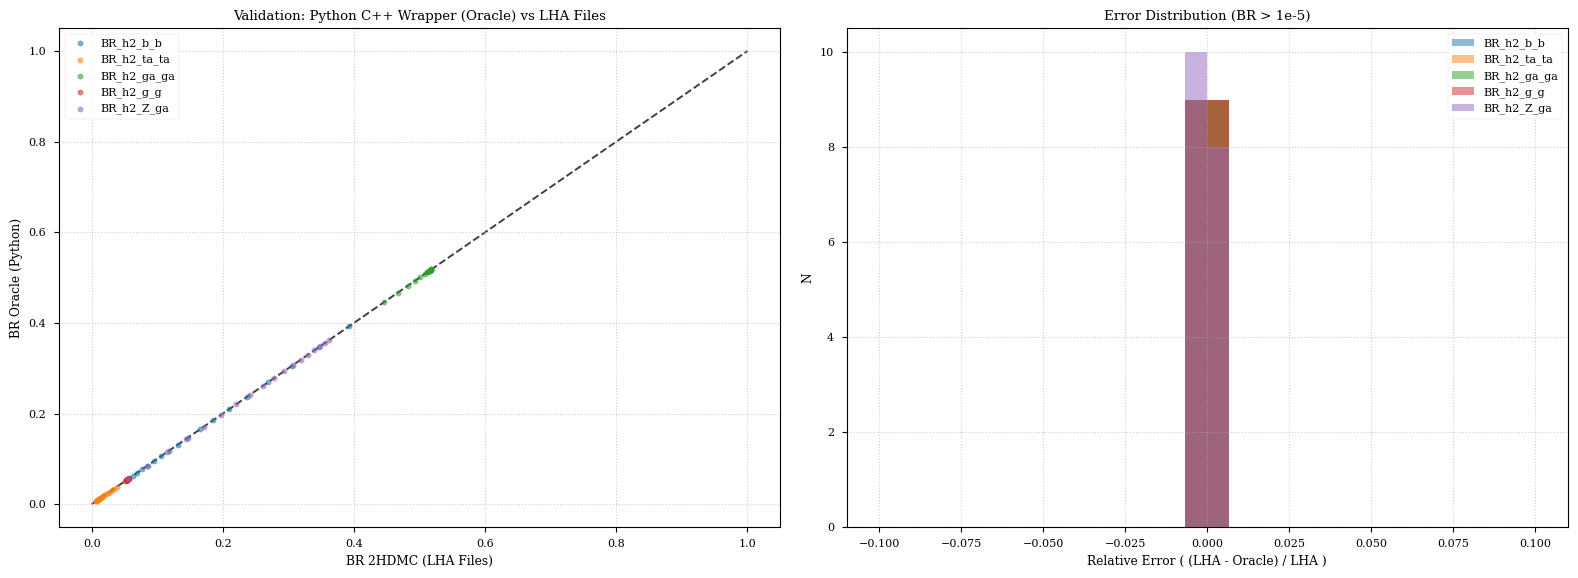


--- REPORTE DE DESVIACIONES ---
Canal BR_h2_b_b       | MAE: 1.45e-05
Canal BR_h2_ta_ta     | MAE: 1.50e-06
Canal BR_h2_ga_ga     | MAE: 1.57e-05
Canal BR_h2_g_g       | MAE: 4.56e-06
Canal BR_h2_Z_ga      | MAE: 5.61e-06


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lib.oracle import safe_run_oracle # Asumiendo que esta es tu importación

# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURACIÓN DEL MAPEO (Oracle Key -> DataFrame Column)
# ─────────────────────────────────────────────────────────────────────────────
# Clave del dict del Oracle : Sufijo de la columna en tu DF (ajustado al paso anterior)
# Nota: Ajusta los nombres de la derecha según como quedaron en tu CSV 'valid_points_extended.csv'
COMPARISON_MAP = {
    'w_h2_bb':      'BR_h2_b_b',
    'w_h2_tautau':  'BR_h2_ta_ta',
    'w_h2_gaga':    'BR_h2_ga_ga',
    'w_h2_gg':      'BR_h2_g_g',
    'w_h2_Zga':     'BR_h2_Z_ga',
    # Nota sobre 'vv': El oracle devuelve una lista, requiere tratamiento especial.
    # Si w_h2_vv[0] es WW y w_h2_vv[1] es ZZ (o viceversa), hay que verificarlo.
    # Por ahora omitimos vectores masivos para evitar errores de índice sin saber la estructura de tu lista.
}

# ─────────────────────────────────────────────────────────────────────────────
# 2. GENERACIÓN DE PREDICCIONES
# ─────────────────────────────────────────────────────────────────────────────
print("Ejecutando oráculo para validación cruzada...")

predictions = []

for idx, row in df.iterrows():
    # ⚠️ CRÍTICO: Asegúrate de pasar TODOS los parámetros que varían en tu DF.
    # Si tanbeta, sin_ba, etc., cambian fila a fila, debes pasarlos aquí.
    # Basado en tu ejemplo, paso los mínimos, pero dejo comentados los otros.
    
    # Extraer valores de la fila actual del DF
    mphi_val  = row['Mh2']
    m12_2_val = row['m12_2']
    
    # Si estos varían en tu DF, descomenta y úsalos:
    # ma_val      = row['Mh3']      # Asumiendo que mA es Mh3
    # tanbeta_val = row['tan_beta']
    # sin_ba_val  = row['sin_ba']
    # l6_val      = row['lambda6']
    # l7_val      = row['lambda7']

    # Llamada al oráculo (Ajusta los argumentos según la firma real de tu función)
    # Usamos try/except por si el oráculo falla en algún punto físico
    try:
        # AQUÍ ESTOY USANDO LOS VALORES POR DEFECTO DEL EJEMPLO PARA LOS NO-ESPECIFICADOS
        # DEBES ACTUALIZAR ESTO SI TUS DATOS TIENEN TANBETA VARIABLE
        res = safe_run_oracle([
            mphi_val, 
            300.0,   # mA (fijo según tu ejemplo, cambiar si es variable)
            1.0,     # sin_ba
            10000.0, # tanbeta
            0.1,     # lambda6
            0.0,     # lambda7
            m12_2_val
        ])
        
        # Calcular Branching Ratios Predichos
        w_total = res['w_total_h2']
        pred_row = {'index': idx, 'w_total_oracle': w_total}
        
        if w_total > 0:
            for oracle_key, df_col in COMPARISON_MAP.items():
                if oracle_key in res:
                    # BR = width_parcial / width_total
                    pred_row[f"PRED_{df_col}"] = res[oracle_key] / w_total
        
        predictions.append(pred_row)
        
    except Exception as e:
        print(f"Error en fila {idx}: {e}")

# Crear DF de predicciones
df_pred = pd.DataFrame(predictions).set_index('index')

# Unir con el DF original (inner join por índice)
df_merged = df.join(df_pred)

# ─────────────────────────────────────────────────────────────────────────────
# 3. ANÁLISIS NUMÉRICO Y VISUALIZACIÓN
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Definir qué canales graficar
channels_to_plot = list(COMPARISON_MAP.values())

# --- Gráfico 1: Correlación (Diagonal Plot) ---
ax = axes[0]
for col in channels_to_plot:
    pred_col = f"PRED_{col}"
    if pred_col in df_merged.columns:
        ax.scatter(df_merged[col], df_merged[pred_col], label=col, alpha=0.6, s=15)

# Línea de identidad perfecta
lims = [0, 1] # BR va de 0 a 1
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.set_xlabel('BR 2HDMC (LHA Files)')
ax.set_ylabel('BR Oracle (Python)')
ax.set_title('Validation: Python C++ Wrapper (Oracle) vs LHA Files')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

# --- Gráfico 2: Residuales Relativos ((Obs - Pred) / Obs) ---
ax = axes[1]
for col in channels_to_plot:
    pred_col = f"PRED_{col}"
    if pred_col in df_merged.columns:
        # Calcular error relativo (evitando división por cero)
        # Filtramos donde el BR es significativo (> 1e-5) para evitar ruido numérico
        mask = df_merged[col] > 1e-5
        if mask.sum() > 0:
            rel_error = (df_merged.loc[mask, col] - df_merged.loc[mask, pred_col]) / df_merged.loc[mask, col]
            ax.hist(rel_error, bins=30, alpha=0.5, label=col, range=(-0.1, 0.1))

ax.set_xlabel('Relative Error ( (LHA - Oracle) / LHA )')
ax.set_ylabel('N')
ax.set_title('Error Distribution (BR > 1e-5)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4. REPORTE DE ERRORES MAYORES
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- REPORTE DE DESVIACIONES ---")
for col in channels_to_plot:
    pred_col = f"PRED_{col}"
    if pred_col in df_merged.columns:
        # Error Absoluto Medio (MAE)
        mae = (df_merged[col] - df_merged[pred_col]).abs().mean()
        print(f"Canal {col:15s} | MAE: {mae:.2e}")